In [1]:
!pip install -q transformers datasets
!pip install mtcnn
!pip install tensorflow
!pip install lz4

In [2]:
from datasets import load_dataset
import tensorflow as tf
from transformers import ViTImageProcessor, TFViTModel
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dataset = load_dataset("tonyassi/celebrity-1000", split="train")

selected_old_ids = range(10)
print("Original label IDs used:", selected_old_ids)
print("Total images before filtering:", len(dataset))

def filter_10(example):
    return example["label"] in selected_old_ids

dataset = dataset.filter(filter_10)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Original label IDs used: range(0, 10)
Total images before filtering: 18184


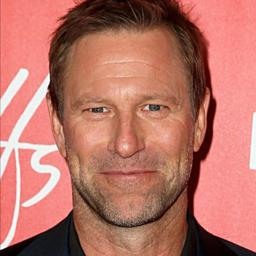

In [4]:
dataset[0]['image']

In [5]:
print(len(selected_old_ids))

10


In [6]:
dataset.shape

(160, 2)

In [7]:
MODEL_NAME = "google/vit-base-patch16-224-in21k"

embedder = TFViTModel.from_pretrained(MODEL_NAME, from_pt=True)

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


In [8]:
print(processor)

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [9]:
embedder.config

ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "transformers_version": "4.57.3"
}

In [10]:
def preprocess(batch):
    processed_image = processor(images=batch["image"], return_tensors="np")
    return {"pixel_values": processed_image["pixel_values"]}

In [11]:
dataset = dataset.map(preprocess, batched=True)

In [12]:
dataset

Dataset({
    features: ['image', 'label', 'pixel_values'],
    num_rows: 160
})

In [13]:
ds = dataset.with_format("tensorflow")
tf_ds = dataset.to_tf_dataset(
    columns=["pixel_values"],
    label_cols=["label"],
    batch_size=64,
    shuffle=False
)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


In [14]:
all_embeddings = []

for batch, labels in tf_ds:
    outputs = embedder(batch)
    emb = outputs.pooler_output
    all_embeddings.append(emb)

In [15]:
all_embeddings = np.concatenate(all_embeddings,axis=0)
all_embeddings.shape

(160, 768)

In [16]:
emb_list = [emb for emb in all_embeddings]
dataset = dataset.add_column("embedding", emb_list)

In [17]:
ds=dataset.remove_columns(['pixel_values',"image"])
ds

Dataset({
    features: ['label', 'embedding'],
    num_rows: 160
})

Load & split celebrity-1000 (70/10/20)

In [18]:
dataset_shuffled = ds.shuffle(seed=42)

train_temp = dataset_shuffled.train_test_split(test_size=0.30, seed=42, stratify_by_column='label')
train_ds = train_temp["train"]
temp_ds  = train_temp["test"]

val_test = temp_ds.train_test_split(test_size=2/3, seed=42)
val_ds = val_test["train"]
test_ds = val_test["test"]

num_classes = len(selected_old_ids)

In [19]:
train_ds.shape

(112, 2)

In [20]:
x_train = np.array(train_ds["embedding"])
y_train = np.array(train_ds["label"])
x_val = np.array(val_ds["embedding"])
y_val = np.array(val_ds["label"])
x_test = np.array(test_ds["embedding"])
y_test = np.array(test_ds["label"])

In [21]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    layers.Input(shape=(768,)),
    # layers.Dense(256, activation='relu'),
    # layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,722 (389.54 KB)

 Trainable params: 99,722 (389.54 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history=model.fit(x_train, y_train, epochs=15, validation_data=(x_val, y_val))

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 638ms/step - accuracy: 0.1138 - loss: 2.4169 - val_accuracy: 0.6250 - val_loss: 1.7771
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5856 - loss: 1.7213 - val_accuracy: 0.6250 - val_loss: 1.4288
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6610 - loss: 1.3365 - val_accuracy: 0.6250 - val_loss: 1.1471
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7856 - loss: 1.0627 - val_accuracy: 0.8125 - val_loss: 0.9325
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7996 - loss: 0.8087 - val_accuracy: 0.9375 - val_loss: 0.7809
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8609 - loss: 0.6736 - val_accuracy: 0.8750 - val_loss: 0.6742
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8728 - loss: 0.5513 - val_accuracy: 0.8750 - val_loss: 0.5779
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8454 - loss: 0.5531 - val_accuracy: 1.0000 - val_loss: 0.5190

We’ll also update the classifier label mapping:

In [25]:
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.8125 - loss: 0.6003
Accuracy: 0.8125


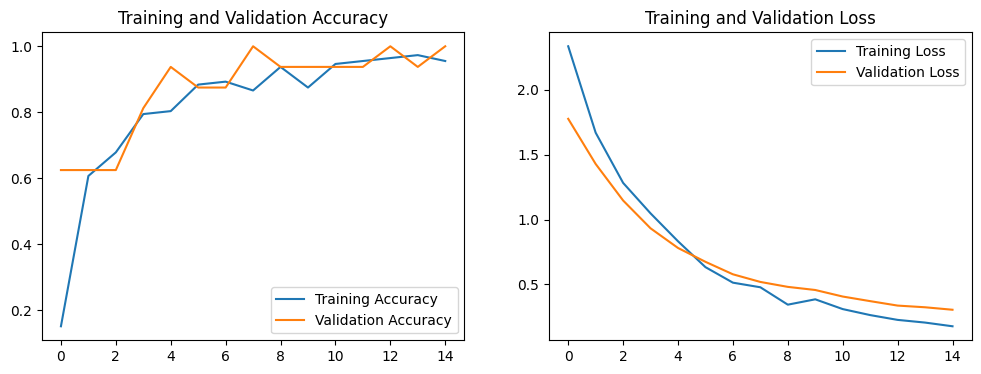

In [26]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history)

In [27]:
from sklearn.metrics import classification_report

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.array(y_test)

class_names = dataset.features["label"].names[:10]

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Classification Report:

                      precision    recall  f1-score   support

       Aaron Eckhart     0.8000    1.0000    0.8889         4
          Aaron Paul     0.8000    0.8000    0.8000         5
       Aaron Rodgers     1.0000    1.0000    1.0000         4
Aaron Taylor-Johnson     0.7500    0.7500    0.7500         4
       Abbi Jacobson     0.5000    0.5000    0.5000         2
   Abhishek Bachchan     1.0000    1.0000    1.0000         2
     Abigail Breslin     1.0000    0.7500    0.8571         4
     Abigail Spencer     0.8000    1.0000    0.8889         4
          Adam Brody     0.0000    0.0000    0.0000         1
         Adam Devine     0.5000    0.5000    0.5000         2

            accuracy                         0.8125        32
           macro avg     0.7150    0.7300    0.7185        32
        weighted avg     0.7937    0.8125    0.7981        32



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


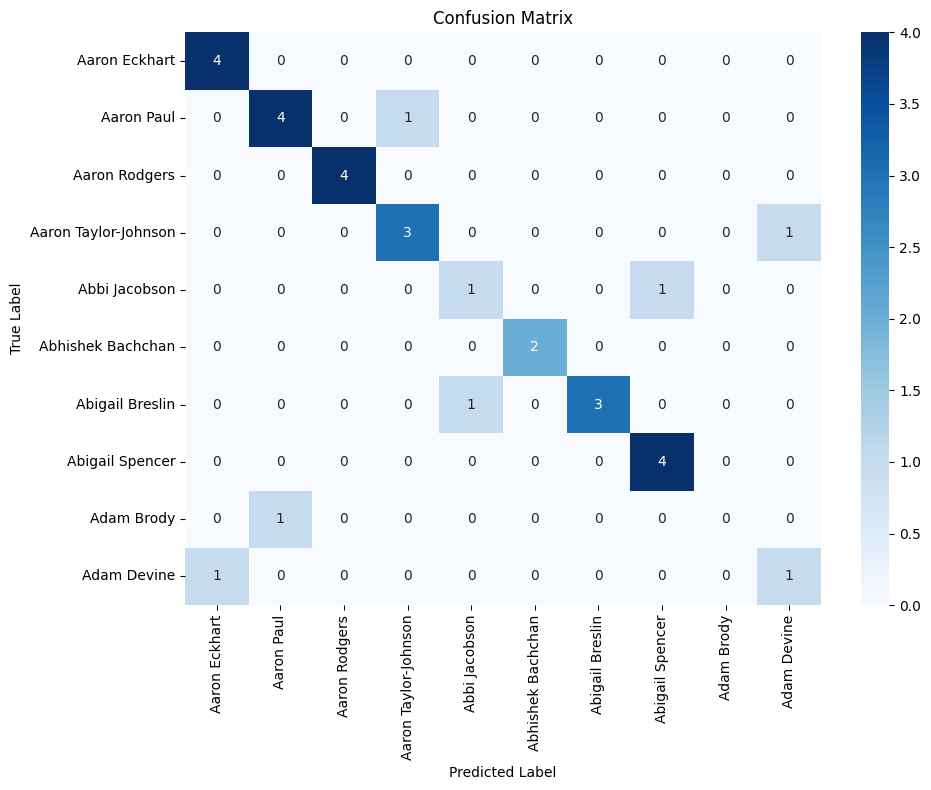

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(y_test)

class_names = dataset.features["label"].names[:10]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [29]:
def preprocess_input_image(img):
    # Convert PIL → model tensor
    inputs = processor(images=img, return_tensors="tf")
    tensor_img = inputs["pixel_values"]

    # Additional normalization and enhancement
    tensor_img = tf.image.per_image_standardization(tensor_img)

    return tensor_img


In [30]:
from mtcnn import MTCNN
import cv2

detector = MTCNN()

def crop_face_mtcnn(img, required_size=(224, 224)):

    results = detector.detect_faces(img)
    if len(results) == 0:
        return None

    x, y, w, h = results[0]['box']

    x = max(0, x)
    y = max(0, y)
    x2 = min(x + w, img.shape[1])
    y2 = min(y + h, img.shape[0])

    face = img[y:y2, x:x2]

    if face.size == 0:
        return None

    face = cv2.resize(face, required_size)

    return face

In [31]:
def get_prediction(img_pil, top_k=None):
    tensor_img = preprocess_input_image(img_pil)
    outputs = embedder(tensor_img)
    emb = outputs.pooler_output   # (batch, 768)

    preds = model.predict(emb)    # (1, num_classes)
    preds = np.asarray(preds)

    if preds.ndim == 2 and preds.shape[0] == 1:
        scores = preds[0]
    else:
        scores = preds.ravel()

    s = float(np.sum(scores))
    if abs(s - 1.0) < 1e-3 and np.all(scores >= 0):

        probs = scores
        used_softmax = False
    else:

        probs = tf.nn.softmax(scores).numpy()
        used_softmax = True

    predicted_class = int(np.argmax(scores))
    predicted_prob = float(probs[predicted_class]) * 100.0
    print("\n=== Prediction summary ===")
    print(f"Softmax applied: {used_softmax}")
    print(f"Predicted Class Index: {predicted_class}")
    try:
        name = dataset.features['label'].names[predicted_class]
    except Exception:
        name = str(predicted_class)
    print(f"Name: {name}")
    print(f"Confidence: {predicted_prob:.2f}%")

    sorted_indices = np.argsort(probs)[::-1]
    if top_k is not None:
        sorted_indices = sorted_indices[:top_k]
    print("\nClasses (sorted by probability):")
    for rank, idx in enumerate(sorted_indices, start=1):
        try:
            cls_name = dataset.features['label'].names[int(idx)]
        except Exception:
            cls_name = str(int(idx))
        conf = probs[int(idx)] * 100.0
        print(f"{rank:02d}. Index: {int(idx):3d}  Name: {cls_name:20s}  Confidence: {conf:6.2f}%")

    return scores, probs, sorted_indices


In [32]:
dataset.features['label'].names[:10]

['Aaron Eckhart',
 'Aaron Paul',
 'Aaron Rodgers',
 'Aaron Taylor-Johnson',
 'Abbi Jacobson',
 'Abhishek Bachchan',
 'Abigail Breslin',
 'Abigail Spencer',
 'Adam Brody',
 'Adam Devine']

Saving Aaron Paul.webp to Aaron Paul (3).webp


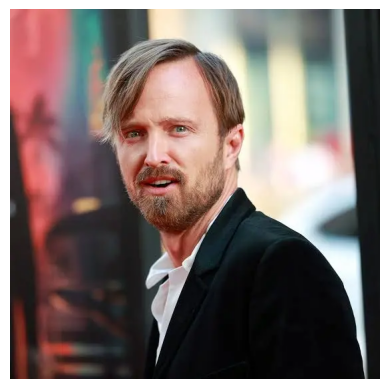

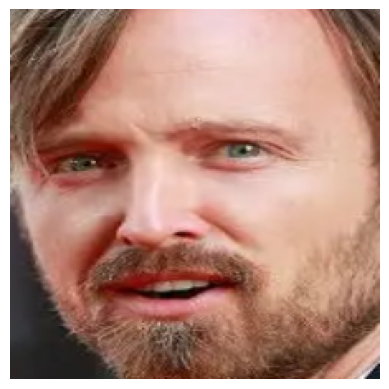

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step

=== Prediction summary ===
Softmax applied: False
Predicted Class Index: 1
Name: Aaron Paul
Confidence: 47.86%

Classes (sorted by probability):
01. Index:   1  Name: Aaron Paul            Confidence:  47.86%
02. Index:   5  Name: Abhishek Bachchan     Confidence:  16.46%
03. Index:   3  Name: Aaron Taylor-Johnson  Confidence:  12.73%
04. Index:   2  Name: Aaron Rodgers         Confidence:   6.45%
05. Index:   8  Name: Adam Brody            Confidence:   6.30%
06. Index:   0  Name: Aaron Eckhart         Confidence:   5.73%
07. Index:   4  Name: Abbi Jacobson         Confidence:   2.60%
08. Index:   7  Name: Abigail Spencer       Confidence:   0.71%
09. Index:   6  Name: Abigail Breslin       Confidence:   0.60%
10. Index:   9  Name: Adam Devine           Confidence:   0.55%


In [33]:
from google.colab import files
from PIL import Image

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_pil = Image.open(filename).convert("RGB")
img = np.array(img_pil).astype('uint8')

plt.imshow(img)
plt.axis('off')
plt.show()

cropped = crop_face_mtcnn(img)
if cropped is not None:
  cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
  plt.imshow(cropped)
  plt.axis('off')
  plt.show()
else:
  print("No face detected")

if cropped is None:
  print("No face detected")
else:
  get_prediction(cropped)

In [34]:
def crop_face_for_vit(img_pil, detector, size=(224,224)):
    img = np.array(img_pil)
    results = detector.detect_faces(img)

    if len(results) == 0:
        return img_pil  # fallback

    x, y, w, h = results[0]["box"]
    x, y = max(0, x), max(0, y)
    face = img[y:y+h, x:x+w]

    face = cv2.resize(face, size)
    return Image.fromarray(face)

In [35]:
def get_vit_attention(model, inputs):
    outputs = model(
        inputs,
        output_attentions=True,
        training=False
    )
    return outputs.attentions


In [36]:
def grad_attention_rollout(model, inputs):
    with tf.GradientTape() as tape:
        outputs = model(inputs, output_attentions=True)
        logits = outputs.last_hidden_state[:, 0, :]
        score = tf.reduce_max(logits)

    grads = tape.gradient(score, outputs.attentions)

    attn = np.mean(
        [a.numpy() for a in outputs.attentions[-5:]],
        axis=0
    )
    grad = np.mean(
        [g.numpy() for g in grads[-5:]],
        axis=0
    )


    attn = attn.mean(axis=1) # Average heads
    grad = grad.mean(axis=1)

    cam = attn * grad
    cam = cam[0, 0, 1:]

    num_patches = int(np.sqrt(len(cam)))
    heatmap = cam.reshape(num_patches, num_patches)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= heatmap.max()

    return heatmap



In [37]:
def prepare_vit_image(img):
    inputs = processor(images=img, return_tensors="tf")
    return inputs["pixel_values"]


In [38]:
def show_vit_attention(img, heatmap, alpha=0.5):
    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        (img.size[1], img.size[0])
    ).numpy().squeeze()

    plt.imshow(img)
    plt.imshow(heatmap, cmap="jet", alpha=alpha)
    plt.axis("off")
    plt.show()


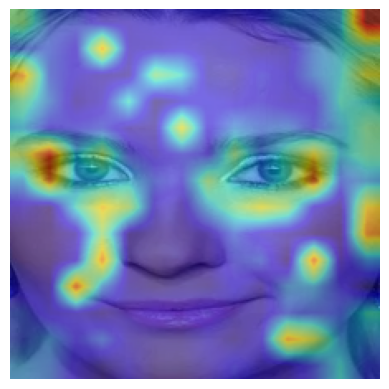

In [39]:
detector = MTCNN()

face_img = Image.open("/content/Abigail Breslin.jpeg").convert("RGB")

face_img = crop_face_for_vit(face_img, detector)

inputs = prepare_vit_image(face_img)
attentions = get_vit_attention(embedder, inputs)

heatmap = grad_attention_rollout(embedder, inputs)
show_vit_attention(face_img, heatmap)